# 

In [5]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

os.environ.setdefault('XDG_CACHE_HOME', str(Path('.cache').resolve()))
os.environ.setdefault('MPLCONFIGDIR', str(Path('.cache/matplotlib').resolve()))

import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
# import xgcm
import cartopy.crs as ccrs
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from oceanttds import * 
from tqdm.notebook import tqdm
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

import jax
import jax.numpy as jnp
import numpyro
import xarray_jax  # noqa: F401 - registers xarray objects as JAX pytrees
from numpyro import distributions as dist, sample
from numpyro.infer import MCMC, NUTS, Predictive
import string
import matplotlib.pyplot as plt
import seaborn as sns
import cmocean.cm as cmo
numpyro.set_host_device_count(8)
jax.local_device_count()


8

In [3]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/bayesian_inverse_gaussian_results.nc"
merged_bayes_ds = xr.open_dataset(ds_path)

prior = merged_bayes_ds.sel(distribution = "prior")
posterior = merged_bayes_ds.sel(distribution = "posterior")

ds_i =  merged_bayes_ds[[v for v in merged_bayes_ds if "interior_time" in merged_bayes_ds[v].dims]].rename({"interior_time":"time"})
ds_b =  merged_bayes_ds[[v for v in merged_bayes_ds if "boundary_time" in merged_bayes_ds[v].dims]].rename({"boundary_time":"time"})

In [4]:
bayes_integrator = TTDIntegrator(order=101)

def ensemble_mixture(samples):
    return EnsembleMixture(
        components=[
            (
                InverseGaussian,
                {
                    'gamma': samples['gamma'].sel(source=source),
                    'delta': samples['delta'].sel(source=source),
                },
            )
            for source in samples.source.values
        ],
        weights=samples['mass_fraction'],
        component_dim='source',
    )

prior_ensemble = ensemble_mixture(prior)
posterior_ensemble = ensemble_mixture(posterior)

In [15]:
from plot_ig_utils import *
from utils import *

posterior_da = bayes_integrator.predict_sources(
    age=prior_ensemble,
    obs_times=ds_i['time'],
    boundary=ds_b['boundary'],
)

posterior_da = bayes_integrator.predict_sources(
    age=posterior_ensemble,
    obs_times=ds_i['time'],
    boundary=ds_b['boundary'],
)

posterior_da_components = bayes_integrator.predict_sources(
    age=posterior_ensemble,
    obs_times=ds_i['time'],
    boundary=ds_b['boundary'],
    return_components = True
)

for expt in ds_b.expt.values:
    posterior_mse = mse_score(posterior_da.sel(expt = expt), ds_i['interior'].sel(expt = expt),  ds_i['sigma_obs'].sel(expt = expt))
    print(
        f'{expt}: posterior predictive RMSE = '
        f"{float(posterior_mse['rmse'].quantile(0.5)):.4g} "
        f"[{float(posterior_mse['rmse'].quantile(0.025)):.4g}, {float(posterior_mse['rmse'].quantile(0.975)):.4g}]"
    )

control: posterior predictive RMSE = 6.609 [6.608, 6.61]
forced: posterior predictive RMSE = 17.17 [17.17, 17.17]


In [10]:
%%time 
#takes up to 2 min
tau_plot = xr.DataArray(np.geomspace(1e-3, 20000.0, 300), dims='tau', name='tau', attrs={'units': 'years'})
prior_age_samples = prior_ensemble.pdf(tau_plot)
posterior_age_samples = posterior_ensemble.pdf(tau_plot)

CPU times: user 54 s, sys: 1.55 s, total: 55.6 s
Wall time: 47.5 s


In [11]:
%%time
prior_age_cdf = prior_ensemble.cdf(tau_plot)
posterior_age_cdf = posterior_ensemble.cdf(tau_plot)

CPU times: user 1min 8s, sys: 1.54 s, total: 1min 9s
Wall time: 1min 3s


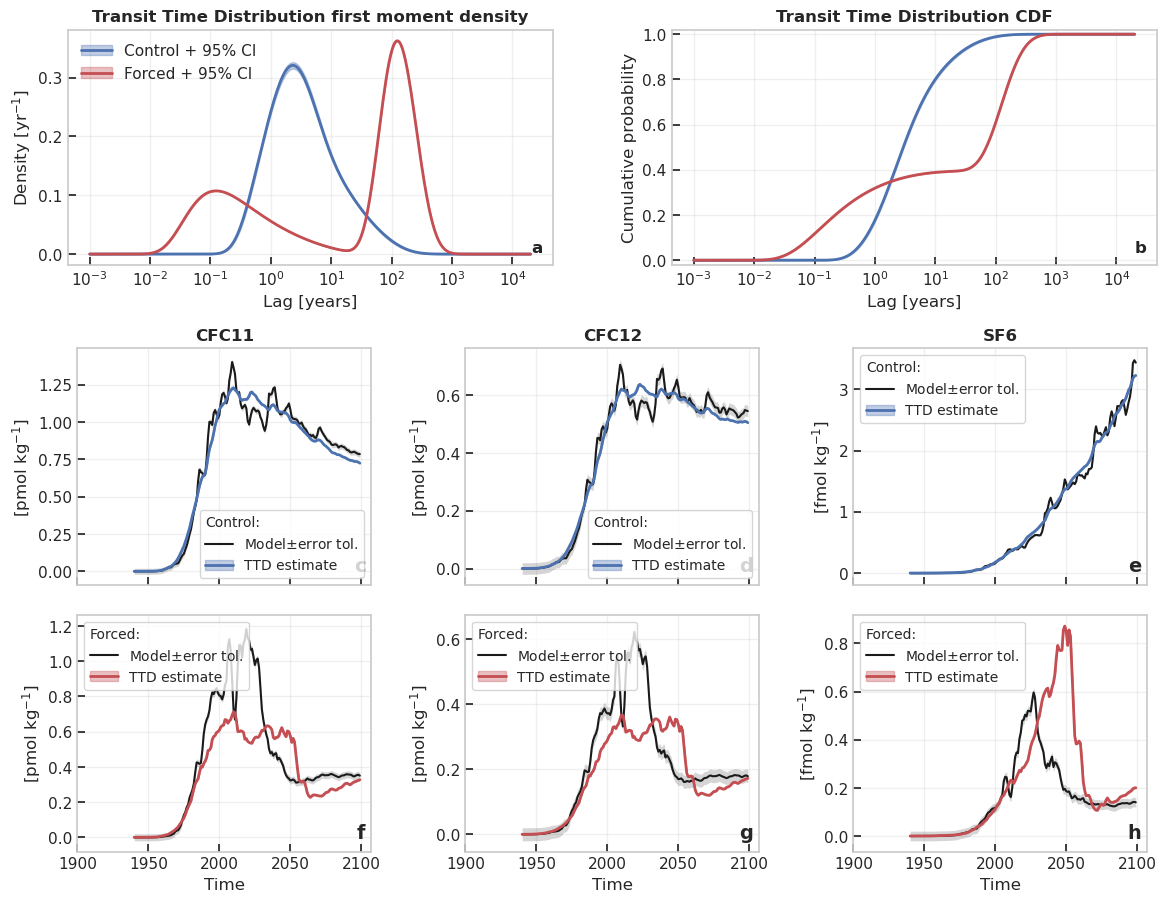

In [35]:
expt_colors = {"forced":"r", "control":"b"}
variable_units = {"cfc11":r"pmol kg$^{-1}$", "cfc12":r"pmol kg$^{-1}$", "sf6":r"fmol kg$^{-1}$"}

def plot_error_band(ax, time, history, error, label, color, legend=None, alpha=0.25):
    legend = {} if legend is None else legend
    ax.fill_between(time, history - 2 * error, history + 2 * error,
                    color=color, alpha=alpha, linewidth=0)
    line, = ax.plot(time, history, color=color)
    legend[label] = line
    return legend


sns.set_theme(style="whitegrid", context="notebook")

expts, tracers = list(ds_b.expt.values), list(ds_i.tracer.values)
nrows, ncols = len(expts) + 1, len(tracers)

fig = plt.figure(figsize=(3.5 * ncols * 1.1, 2.7 * nrows * 1.1),
                 constrained_layout=True)

gs = fig.add_gridspec(nrows, ncols, height_ratios=[1.3] + [1.0] * len(expts),
                      hspace=0.1, wspace=0.07)

gs_ttd = gs[0, :].subgridspec(1, 2, wspace=0.12)
ax_pdf = fig.add_subplot(gs_ttd[0, 0])
ax_cdf = fig.add_subplot(gs_ttd[0, 1], sharex=ax_pdf)

ttd_legend = {}

for expt in expts:
    expt_str = str(expt)
    color = expt_colors[expt_str]
    label = f"{expt_str.capitalize()} + 95% CI"

    plot_distribution(ax_pdf, tau_plot, tau_plot * posterior_age_samples.sel(expt=expt),
                      color, label, legend=ttd_legend)

    plot_distribution(ax_cdf, tau_plot, posterior_age_cdf.sel(expt=expt),
                      color, label, legend=None)

ax_pdf.set(xscale="log", title="Transit Time Distribution first moment density",
           xlabel="Lag [years]", ylabel=r"Density")
ax_cdf.set(xscale="log", title="Transit Time Distribution CDF",
           xlabel="Lag [years]", ylabel="Cumulative probability",
           ylim=(-0.02, 1.02))

for ax, letter in zip([ax_pdf, ax_cdf], ["a", "b"]):
    ax.title.set_fontweight("bold")
    ax.text(0.98, 0.04, letter, transform=ax.transAxes,
            ha="right", va="bottom", fontweight="bold")

ax_pdf.legend(ttd_legend.values(), ttd_legend.keys(), frameon=False)

ax_ref = None
panel_letters = iter(string.ascii_lowercase[2:])

for row, expt in enumerate(expts, start=1):
    color = expt_colors[str(expt)]

    for col, tracer in enumerate(tracers):
        ax = fig.add_subplot(gs[row, col], sharex=ax_ref)
        ax_ref = ax if ax_ref is None else ax_ref

        tracer = str(tracer)
        units = variable_units.get(tracer, "concentration")
        legend = {}

        plot_error_band(ax, ds_i.time,
                        ds_i.interior.sel(tracer=tracer, expt=expt),
                        ds_i.sigma_obs.sel(tracer=tracer, expt=expt),
                        r"Model$\pm$error tol.", "k", legend=legend, alpha=0.18)

        plot_distribution(ax, ds_i.time,
                          posterior_da.sel(tracer=tracer, expt=expt),
                          color, "TTD estimate", legend=legend)

        ax.set_ylabel(f"[{units}]")
        ax.legend(legend.values(), legend.keys(),
                  title=str(expt).capitalize() + ":",
                  fontsize=10, title_fontsize=10, alignment="left")

        if row == 1:
            ax.set_title(str(tracer).upper(), fontweight="bold")
        if row == len(expts):
            ax.set_xlabel("Time")
        else:
            ax.tick_params(labelbottom=False)

        ax.text(0.98, 0.04, next(panel_letters), transform=ax.transAxes,
                ha="right", va="bottom", fontweight="bold", fontsize=14)
        ax.set_xlim(1900, None)

for ax in fig.axes:
    ax.grid(alpha=0.3)
    ax.tick_params(direction="in", bottom=True, left=True,
                   top=False, right=False)

fig.savefig("plots/2.ttd_inversion_results.png", dpi=150, bbox_inches="tight")

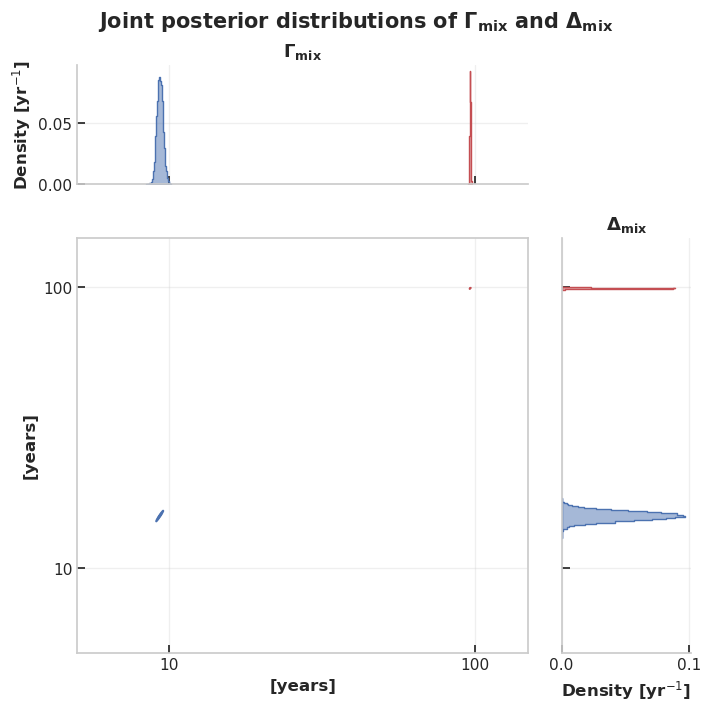

In [17]:
fig = plt.figure(figsize=(7.0, 7.0), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=(4.0, 1.15),
                      height_ratios=(1.15, 4.0), wspace=0.06, hspace=0.06)

ax_g = fig.add_subplot(gs[0, 0])
ax_j = fig.add_subplot(gs[1, 0], sharex=ax_g)
ax_d = fig.add_subplot(gs[1, 1], sharey=ax_j)

def get_gamma_delta(expt):
    p = posterior.sel(expt=expt)
    g, d = np.asarray(p["gamma_mix"]).ravel(), np.asarray(p["delta_mix"]).ravel()
    keep = np.isfinite(g) & np.isfinite(d)
    return g[keep], d[keep]

hist = lambda **k: sns.histplot(bins=35, stat="probability", element="step",
                                alpha=0.5, fill=True, common_norm=False, **k)

kde = lambda g, d, c: sns.kdeplot(x=g, y=d, levels=(0.50, 0.80, 0.95),
                                  fill=False, thresh=0.0, color=c,
                                  linewidths=1.3, ax=ax_j)

offsets = {"forced": (-90, 10), "control": (30, 11)}
gamma_label_y = {"forced": 0.82, "control": 0.90}


gamma_text = r"\mathbf{\Gamma_{\mathbf{mix}}}"
delta_text = r"\mathbf{\Delta_{\mathbf{mix}}}"
for expt in ("forced", "control"):
    color = expt_colors[expt]
    gamma, delta = get_gamma_delta(expt)
    gamma_med, delta_med = compute_geometric_median(np.column_stack([gamma, delta])).median

    hist(x=gamma, color=color, ax=ax_g)
    hist(y=delta, color=color, ax=ax_d)
    kde(gamma, delta, color)

    # ax_j.scatter(gamma_med, delta_med, s=55, color=color, edgecolor="k",
    #              linewidth=0.8, zorder=10)
    # ax_j.annotate("Geom. median:\n" + rf"${gamma_text}=${gamma_med:.1f}" + "\n" + rf"${delta_text}=${delta_med:.1f}",
    #               xy=(gamma_med, delta_med), xytext=offsets[expt],
    #               textcoords="offset points", ha="left", fontweight = "bold", 
    #               va="bottom" if offsets[expt][1] >= 0 else "top",
    #               fontsize=12, color=color)

    # ax_g.annotate(expt.capitalize(), xy=(np.nanmedian(gamma) - 7, gamma_label_y[expt]),
    #               xycoords=("data", "axes fraction"), ha="center", va="center",
    #               fontsize=12, fontweight="bold", color=color)

ax_g.set(title=r"$\mathbf{\Gamma_{\mathbf{mix}}}$",
         ylabel=r"Density [yr$^{-1}$]")
ax_d.set(title=r"$\mathbf{\Delta_{\mathbf{mix}}}$",
         xlabel=r"Density [yr$^{-1}$]")
ax_j.set(xlabel=r"[years]",
         ylabel=r"[years]")

ax_g.tick_params(labelbottom=False)
ax_d.tick_params(labelleft=False)

for ax in (ax_g, ax_d):
    ax.title.set(fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

for label in (ax_g.yaxis.label, ax_d.xaxis.label, ax_j.xaxis.label, ax_j.yaxis.label):
    label.set_fontweight("bold")
[a.grid(alpha = 0.3) for a in [ax_g, ax_d, ax_j]]

fig.suptitle(rf"Joint posterior distributions of ${gamma_text}$ and ${delta_text}$",
             fontsize=15, fontweight="bold")

# Switch axes to log scale to compress the empty space
ax_j.set_xscale('log')
ax_j.set_yscale('log')

# Set tight limits (log scale can't start at 0)
ax_j.set_xlim(5, 150)
ax_j.set_ylim(5, 150)

# Clean up the ticks so they display as normal numbers instead of scientific notation
import matplotlib.ticker as ticker
ax_j.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax_j.yaxis.set_major_formatter(ticker.ScalarFormatter())

for ax in fig.axes:
    ax.tick_params(direction="in", bottom=True, left=True,
                   top=False, right=False)
    

(<matplotlib.lines.Line2D at 0x2ab164242990>,
 <matplotlib.collections.FillBetweenPolyCollection at 0x2ab164242ad0>)

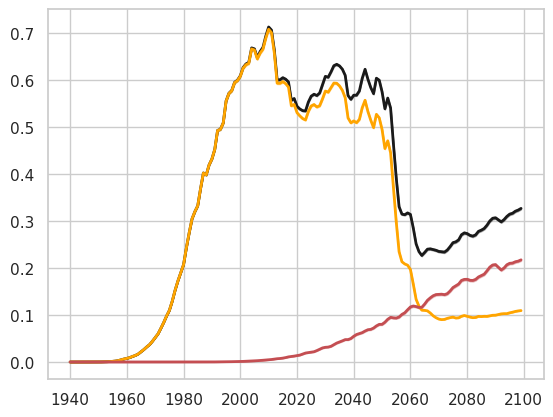

In [36]:
fig, ax = plt.subplots()

ttd_legend = {}

plot_distribution(ax, posterior_da_components.time, posterior_da_components.sel(tracer = "cfc11", expt="forced").sum("_source_term"),
                  "k", "forced_adelie", legend=ttd_legend)


plot_distribution(ax, posterior_da_components.time, posterior_da_components.sel(tracer = "cfc11", expt="forced").isel(_source_term = 0),
                  "orange", "forced_adelie", legend=ttd_legend)

plot_distribution(ax, posterior_da_components.time, posterior_da_components.sel(tracer = "cfc11", expt="forced").isel(_source_term = 1),
                  "r", "forced_ross", legend=ttd_legend)


# plot_distribution(ax_pdf, tau_plot, posterior_da_components.sel(tracer = "SF6", expt="forced", source = "ross"),
#                   "r", "forced_ross", legend=ttd_legend)

(<matplotlib.lines.Line2D at 0x2ab1641be0d0>,
 <matplotlib.collections.FillBetweenPolyCollection at 0x2ab1641be210>)

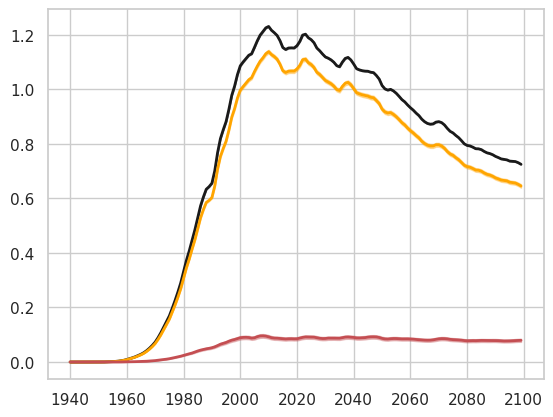

In [37]:
fig, ax = plt.subplots()

ttd_legend = {}

plot_distribution(ax, posterior_da_components.time, posterior_da_components.sel(tracer = "cfc11", expt="control").sum("_source_term"),
                  "k", "forced_adelie", legend=ttd_legend)


plot_distribution(ax, posterior_da_components.time, posterior_da_components.sel(tracer = "cfc11", expt="control").isel(_source_term = 0),
                  "orange", "forced_adelie", legend=ttd_legend)

plot_distribution(ax, posterior_da_components.time, posterior_da_components.sel(tracer = "cfc11", expt="control").isel(_source_term = 1),
                  "r", "forced_ross", legend=ttd_legend)


# plot_distribution(ax_pdf, tau_plot, posterior_da_components.sel(tracer = "SF6", expt="forced", source = "ross"),
#                   "r", "forced_ross", legend=ttd_legend)